In [1]:
import pandas as pd
import numpy as np
from numpy import transpose as T
import glob
import os
import cartopy
import cartopy.crs as ccrs
import matplotlib
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.ticker import MultipleLocator
from matplotlib.gridspec import GridSpec
import matplotlib.cm as cm
import geopandas as gpd
from scipy.optimize import curve_fit
from netCDF4 import Dataset
import scipy
from scipy import stats
from scipy.ndimage import distance_transform_edt
from datetime import datetime,timedelta
from numpy import genfromtxt as gftxt
import regionmask
from pyproj import Transformer
from datetime import datetime,timedelta
import sys
from pathlib import Path

In [2]:
sys.path.append(str(Path.cwd().parents[1]))
from utils.grid_map_functions import(land_masking, defining_grids)

map_projection = ccrs.NorthPolarStereo()

x_grid_edge_25,y_grid_edge_25,new_x_edge_25,new_y_edge_25 = defining_grids(map_projection,[-180, 180, 90, 65],25000,'edge')
x_grid_centre_25,y_grid_centre_25,new_x_centre_25,new_y_centre_25 = defining_grids(map_projection,[-180, 180, 90, 65],25000,'centre')
land_mask_25 = land_masking(new_x_centre_25,new_y_centre_25,map_projection)

transformer = Transformer.from_crs(map_projection, "EPSG:4326", always_xy=True)
lon0, lat0 = transformer.transform(new_x_centre_25.ravel(), new_y_centre_25.ravel())
lon1 = lon0.reshape(new_x_centre_25.shape)
lat1 = lat0.reshape(new_y_centre_25.shape)

from utils.stats_functions import(absdiff,corr,rmsd)

base_dir = ('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Data/')

In [54]:
def retrieving_fractions(input_folder,yrs):
    fractions = {}
    for array in input_folder:
        fraction0 = np.load(array)
        fraction = np.where(land_mask_buffered, np.nan, fraction0)
        fname = os.path.basename(array)
        date = fname.split('_')[0]
        year = str(date[0:4])
        month = str(date[4:6])
        if year in yrs:
            if year == '2018' and int(month) < 10:# don't include jan - apr for 2018
                continue
            if year == '2025' and int(month) > 4: # don't include oct - dec for 2025
                continue
            fractions[date] = fraction
    return(fractions)

def retrieving_fractions_fullrecord(input_folder,yrs):
    fractions = {}
    for array in input_folder:
        fraction0 = np.load(array)
        fraction = np.where(land_mask_buffered, np.nan, fraction0)
        fname = os.path.basename(array)
        date = fname.split('_')[0]
        year = str(date[0:4])
        month = str(date[4:6])
        if year in yrs:
            if year == '2010' and int(month) < 11:
                continue
            if year == '2025' and int(month) > 4: # don't include oct - dec for 2025
                continue
            fractions[date] = fraction
    return(fractions)


def add_land_buffer_distance(land_mask, grid_spacing_km, buffer_km):
    """
    Create buffer based on real distance (km)
    """
    # दूरी from land: compute distance from NON-land
    distance = distance_transform_edt(~land_mask) * grid_spacing_km
    
    # mask where within buffer distance
    buffer_mask = distance <= buffer_km
    
    return land_mask | buffer_mask

def monthly_averages_allyears(fractions_dict,months):
    monthly_groups = {m: [] for m in months}
    for date, arr in fractions_dict.items():
        month = date[4:6]
        if month in monthly_groups:
            monthly_groups[month].append(arr)

    monthly_fractions = {}
    
    for month, arrays in monthly_groups.items():
        stacked = np.stack(arrays, axis=0) 
        monthly_fractions[month] = np.nanmean(stacked, axis=0)

    return(monthly_fractions)

def monthly_averaging_df(input_dict):
    fraction_df = pd.DataFrame({dataset: {month: np.nanmean(arr) for month, arr in monthly_dict.items()}
            for dataset, monthly_dict in input_dict.items()}).sort_index()
    
    fraction_df.index.name = 'Month'
    fraction_df = fraction_df.reset_index()
    return(fraction_df)

land_mask_buffered = add_land_buffer_distance(land_mask_25,grid_spacing_km=25,buffer_km=5)


# Retrieving Fractions 

## Full record

In [48]:
# Read in fraction arrays & find averages
req_yrs = ['2010','2011','2012','2013','2014','2015','2016','2017','2018','2019','2020','2021','2022','2023','2024','2025']

cs2_lead_folder = sorted(glob.glob('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Data/Monthly_Averages/25km/CS2_Corrected/*_Lead_Density.npy'))
cs2_floe_folder = sorted(glob.glob('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Data/Monthly_Averages/25km/CS2_Corrected/*_Floe_Density.npy'))
cs2_lead_fractions = retrieving_fractions(cs2_lead_folder,req_yrs)
cs2_floe_fractions = retrieving_fractions(cs2_floe_folder,req_yrs)

s3_lead_folder = sorted(glob.glob('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Data/Monthly_Averages/25km/S3_Corrected/*_Lead_Density.npy'))
s3_floe_folder = sorted(glob.glob('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Data/Monthly_Averages/25km/S3_Corrected/*_Floe_Density.npy'))
s3_lead_fractions = retrieving_fractions(s3_lead_folder,req_yrs)
s3_floe_fractions = retrieving_fractions(s3_floe_folder,req_yrs)

is2_lead_folder = sorted(glob.glob('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Data/Monthly_Averages/25km/IS2/*_Lead_Density.npy'))
is2_floe_folder = sorted(glob.glob('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Data/Monthly_Averages/25km/IS2/*_Floe_Density.npy'))
is2_lead_fractions = retrieving_fractions(is2_lead_folder,req_yrs)
is2_floe_fractions = retrieving_fractions(is2_floe_folder,req_yrs)

is2_leads_df = pd.DataFrame([{'Date': key, 'Lead Density': np.nanmean(leads)}
    for key, leads in is2_lead_fractions.items()])
is2_leads_df['Datetime'] = pd.to_datetime(is2_leads_df['Date'],format='%Y%m')
is2_leads_df.to_csv('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Data/Monthly_Averages/IS2_Arctic_Monthly_Averages_FullRecord.csv',index=False)
cs2_leads_df = pd.DataFrame([{'Date': key, 'Lead Density': np.nanmean(leads)}
    for key, leads in cs2_lead_fractions.items()])
cs2_leads_df['bDatetime'] = pd.to_datetime(cs2_leads_df['Date'],format='%Y%m')
cs2_leads_df.to_csv('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Data/Monthly_Averages/CS2_Arctic_Monthly_Averages_FullRecord.csv',index=False)
s3_leads_df = pd.DataFrame([{'Date': key, 'Lead Density': np.nanmean(leads)}
    for key, leads in s3_lead_fractions.items()])
s3_leads_df['Datetime'] = pd.to_datetime(s3_leads_df['Date'],format='%Y%m')
s3_leads_df.to_csv('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Data/Monthly_Averages/S3_Arctic_Monthly_Averages_FullRecord.csv',index=False)

## Merging Full Record

In [55]:
cs2_yrs = ['2010','2011','2012','2013','2014','2015','2016','2017',
           '2018','2019','2020','2021','2022','2023','2024','2025']
cs2_lead_folder = sorted(glob.glob('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Data/Monthly_Averages/25km/CS2_Corrected/*_Lead_Density.npy'))
cs2_lead_fractions = retrieving_fractions_fullrecord(cs2_lead_folder,cs2_yrs)

s3_yrs = ['2016','2017','2018','2019','2020','2021','2022','2023','2024','2025']
s3_lead_folder = sorted(glob.glob('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Data/Monthly_Averages/25km/S3_Corrected/*_Lead_Density.npy'))
s3_lead_fractions = retrieving_fractions_fullrecord(s3_lead_folder,s3_yrs)

is2_yrs = ['2018','2019','2020','2021','2022','2023','2024','2025']
is2_lead_folder = sorted(glob.glob('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Data/Monthly_Averages/25km/IS2/*_Lead_Density.npy'))
is2_lead_fractions = retrieving_fractions_fullrecord(is2_lead_folder,is2_yrs)


In [56]:
lead_fractions = [cs2_lead_fractions, is2_lead_fractions, s3_lead_fractions]

merged_lead_fractions = {}
all_dates = sorted(set().union(*[d.keys() for d in lead_fractions]))

for key in all_dates:
    arrays = [d[key] for d in lead_fractions if key in d]
    stacked = np.stack(arrays, axis=0)
    mean_fraction = np.nanmean(stacked, axis=0)
    merged_lead_fractions[key] = mean_fraction
    np.save(f'{base_dir}Monthly_Averages/25km/Merged_Full_Record/{key}_Merged_Lead_Density.npy',
        mean_fraction)

/var/folders/q1/prwbhm6j6x1gcchb7r0p2kyh0000gn/T/ipykernel_49284/435783857.py:9: RuntimeWarning: Mean of empty slice
  mean_fraction = np.nanmean(stacked, axis=0)


In [57]:
lead_fractions = [cs2_lead_fractions, s3_lead_fractions]

merged_lead_fractions = {}
all_dates = sorted(set().union(*[d.keys() for d in lead_fractions]))

for key in all_dates:
    arrays = [d[key] for d in lead_fractions if key in d]
    stacked = np.stack(arrays, axis=0)
    mean_fraction = np.nanmean(stacked, axis=0)
    merged_lead_fractions[key] = mean_fraction
    np.save(f'{base_dir}Monthly_Averages/25km/S3_CS2_Merged_Full_Record/{key}_S3_CS2_Merged_Lead_Density.npy',
        mean_fraction)

/var/folders/q1/prwbhm6j6x1gcchb7r0p2kyh0000gn/T/ipykernel_49284/277172735.py:9: RuntimeWarning: Mean of empty slice
  mean_fraction = np.nanmean(stacked, axis=0)


## Overlapping Record

In [10]:
# Read in fraction arrays & find averages
req_yrs = ['2018','2019','2020','2021','2022','2023','2024','2025']

cs2_lead_folder = sorted(glob.glob('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Data/Monthly_Averages/25km/CS2_Corrected/*_Lead_Density.npy'))
cs2_floe_folder = sorted(glob.glob('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Data/Monthly_Averages/25km/CS2_Corrected/*_Floe_Density.npy'))
cs2_lead_fractions = retrieving_fractions(cs2_lead_folder,req_yrs)
cs2_floe_fractions = retrieving_fractions(cs2_floe_folder,req_yrs)

s3_lead_folder = sorted(glob.glob('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Data/Monthly_Averages/25km/S3_Corrected/*_Lead_Density.npy'))
s3_floe_folder = sorted(glob.glob('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Data/Monthly_Averages/25km/S3_Corrected/*_Floe_Density.npy'))
s3_lead_fractions = retrieving_fractions(s3_lead_folder,req_yrs)
s3_floe_fractions = retrieving_fractions(s3_floe_folder,req_yrs)

is2_lead_folder = sorted(glob.glob('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Data/Monthly_Averages/25km/IS2/*_Lead_Density.npy'))
is2_floe_folder = sorted(glob.glob('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Data/Monthly_Averages/25km/IS2/*_Floe_Density.npy'))
is2_lead_fractions = retrieving_fractions(is2_lead_folder,req_yrs)
is2_floe_fractions = retrieving_fractions(is2_floe_folder,req_yrs)

winter_months = ['10','11','12','01','02','03','04']
cs2_monthly_lead_fractions = monthly_averages_allyears(cs2_lead_fractions,winter_months)
cs2_monthly_floe_fractions = monthly_averages_allyears(cs2_floe_fractions,winter_months)

s3_monthly_lead_fractions = monthly_averages_allyears(s3_lead_fractions,winter_months)
s3_monthly_floe_fractions = monthly_averages_allyears(s3_floe_fractions,winter_months)

is2_monthly_lead_fractions = monthly_averages_allyears(is2_lead_fractions,winter_months)
is2_monthly_floe_fractions = monthly_averages_allyears(is2_floe_fractions,winter_months)

/var/folders/q1/prwbhm6j6x1gcchb7r0p2kyh0000gn/T/ipykernel_49284/2342597747.py:41: RuntimeWarning: Mean of empty slice
  monthly_fractions[month] = np.nanmean(stacked, axis=0)


## Merging Record

In [11]:
lead_fractions = [cs2_lead_fractions, is2_lead_fractions, s3_lead_fractions]
floe_fractions = [cs2_floe_fractions, is2_floe_fractions, s3_floe_fractions]

merged_lead_fractions,merged_floe_fractions = {},{}
for key in lead_fractions[0].keys():
    leads_stacked = np.stack([d[key] for d in lead_fractions], axis=0)
    mean_lead_fraction = np.nanmean(leads_stacked, axis=0)
    merged_lead_fractions[key] = mean_lead_fraction
    np.save('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Data/Monthly_Averages/25km/Merged/'+key+'_Merged_Lead_Density.npy',mean_lead_fraction)
for key in floe_fractions[0].keys():
    floes_stacked = np.stack([d[key] for d in floe_fractions], axis=0)
    mean_floe_fraction = np.nanmean(floes_stacked, axis=0)
    merged_floe_fractions[key] = mean_floe_fraction
    np.save('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Data/Monthly_Averages/25km/Merged/'+key+'_Merged_Floe_Density.npy',mean_floe_fraction)

merged_monthly_lead_fractions = monthly_averages_allyears(merged_lead_fractions,winter_months)
merged_monthly_floe_fractions = monthly_averages_allyears(merged_floe_fractions,winter_months)

/var/folders/q1/prwbhm6j6x1gcchb7r0p2kyh0000gn/T/ipykernel_49284/1643557040.py:7: RuntimeWarning: Mean of empty slice
  mean_lead_fraction = np.nanmean(leads_stacked, axis=0)
/var/folders/q1/prwbhm6j6x1gcchb7r0p2kyh0000gn/T/ipykernel_49284/1643557040.py:12: RuntimeWarning: Mean of empty slice
  mean_floe_fraction = np.nanmean(floes_stacked, axis=0)
/var/folders/q1/prwbhm6j6x1gcchb7r0p2kyh0000gn/T/ipykernel_49284/2342597747.py:41: RuntimeWarning: Mean of empty slice
  monthly_fractions[month] = np.nanmean(stacked, axis=0)


In [12]:
all_lead_fractions = {'CS2':cs2_lead_fractions,'IS2':is2_lead_fractions,
                      'S3':s3_lead_fractions,'Merged':merged_lead_fractions}
lead_fraction_df = monthly_averaging_df(all_lead_fractions)
lead_fraction_df.to_csv('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Data/Monthly_Averages/Merged_Lead_Fraction_Averages.csv',index=False)
all_floe_fractions = {'CS2':cs2_floe_fractions,'IS2':is2_floe_fractions,
                      'S3':s3_floe_fractions,'Merged':merged_floe_fractions}
floe_fraction_df = monthly_averaging_df(all_floe_fractions)
floe_fraction_df.to_csv('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Data/Monthly_Averages/Merged_Floe_Fraction_Averages.csv',index=False)


In [13]:
lead_fractions = [cs2_lead_fractions, s3_lead_fractions]
floe_fractions = [cs2_floe_fractions, s3_floe_fractions]

merged_lead_fractions,merged_floe_fractions = {},{}
for key in lead_fractions[0].keys():
    leads_stacked = np.stack([d[key] for d in lead_fractions], axis=0)
    mean_lead_fraction = np.nanmean(leads_stacked, axis=0)
    merged_lead_fractions[key] = mean_lead_fraction
    np.save('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Data/Monthly_Averages/25km/S3_CS2_Merged/'+key+'_S3_CS2_Merged_Lead_Density.npy',mean_lead_fraction)
for key in floe_fractions[0].keys():
    floes_stacked = np.stack([d[key] for d in floe_fractions], axis=0)
    mean_floe_fraction = np.nanmean(floes_stacked, axis=0)
    merged_floe_fractions[key] = mean_floe_fraction
    np.save('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Data/Monthly_Averages/25km/S3_CS2_Merged/'+key+'_S3_CS2_Merged_Floe_Density.npy',mean_floe_fraction)

merged_monthly_lead_fractions = monthly_averages_allyears(merged_lead_fractions,winter_months)
merged_monthly_floe_fractions = monthly_averages_allyears(merged_floe_fractions,winter_months)

all_lead_fractions = {'CS2':cs2_lead_fractions,
                      'S3':s3_lead_fractions,'Merged':merged_lead_fractions}
lead_fraction_df = monthly_averaging_df(all_lead_fractions)
lead_fraction_df.to_csv('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Data/Monthly_Averages/S3_CS2_Merged_Lead_Fraction_Averages.csv',index=False)
all_floe_fractions = {'CS2':cs2_floe_fractions,
                      'S3':s3_floe_fractions,'Merged':merged_floe_fractions}
floe_fraction_df = monthly_averaging_df(all_floe_fractions)
floe_fraction_df.to_csv('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Data/Monthly_Averages/S3_CS2_Merged_Floe_Fraction_Averages.csv',index=False)


/var/folders/q1/prwbhm6j6x1gcchb7r0p2kyh0000gn/T/ipykernel_49284/2198670295.py:7: RuntimeWarning: Mean of empty slice
  mean_lead_fraction = np.nanmean(leads_stacked, axis=0)
/var/folders/q1/prwbhm6j6x1gcchb7r0p2kyh0000gn/T/ipykernel_49284/2198670295.py:12: RuntimeWarning: Mean of empty slice
  mean_floe_fraction = np.nanmean(floes_stacked, axis=0)
/var/folders/q1/prwbhm6j6x1gcchb7r0p2kyh0000gn/T/ipykernel_49284/2342597747.py:41: RuntimeWarning: Mean of empty slice
  monthly_fractions[month] = np.nanmean(stacked, axis=0)


## Up to 81.5˚ Averages

In [14]:
s3_lat_mask = lat1 > 81.5

cs2_lead_fraction_dict_81,is2_lead_fraction_dict_81,merged_lead_fraction_dict_81 = {},{},{}

for dataset, monthly_dict in cs2_lead_fractions.items():
    cs2_lead_fraction_81 = np.where(s3_lat_mask, np.nan, monthly_dict)
    cs2_lead_fraction_dict_81[dataset] = cs2_lead_fraction_81
for dataset, monthly_dict in is2_lead_fractions.items():
    is2_lead_fraction_81 = np.where(s3_lat_mask, np.nan, monthly_dict)
    is2_lead_fraction_dict_81[dataset] = is2_lead_fraction_81
for dataset, monthly_dict in merged_lead_fractions.items():
    merged_lead_fraction_81 = np.where(s3_lat_mask, np.nan, monthly_dict)
    merged_lead_fraction_dict_81[dataset] = merged_lead_fraction_81

dicts_81 = {'CS2':cs2_lead_fraction_dict_81,'IS2':is2_lead_fraction_dict_81,
           'S3':s3_lead_fractions,'Merged':merged_lead_fraction_dict_81}
lead_fraction_81_df = monthly_averaging_df(dicts_81)
lead_fraction_81_df.to_csv('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Data/Monthly_Averages/81_Latitude_Lead_Fraction_Averages.csv',index=False)

winter_months = ['10','11','12','01','02','03','04']
cs2_monthly_lead_fractions_81 = monthly_averages_allyears(cs2_lead_fraction_dict_81,winter_months)

is2_monthly_lead_fractions_81 = monthly_averages_allyears(is2_lead_fraction_dict_81,winter_months)

merged_monthly_lead_fractions_81 = monthly_averages_allyears(merged_lead_fraction_dict_81,winter_months)

cs2_monthly_lead_flt_81 = {key: arr.flatten() for key, arr in cs2_monthly_lead_fractions_81.items()}
is2_monthly_lead_flt_81 = {key: arr.flatten() for key, arr in is2_monthly_lead_fractions_81.items()}
merged_monthly_lead_flt_81 = {key: arr.flatten() for key, arr in merged_monthly_lead_fractions_81.items()}

/var/folders/q1/prwbhm6j6x1gcchb7r0p2kyh0000gn/T/ipykernel_49284/2342597747.py:41: RuntimeWarning: Mean of empty slice
  monthly_fractions[month] = np.nanmean(stacked, axis=0)


In [15]:
cs2_monthly_lead_flt = {key: arr.flatten() for key, arr in cs2_monthly_lead_fractions.items()}
cs2_monthly_floe_flt = {key: arr.flatten() for key, arr in cs2_monthly_floe_fractions.items()}

s3_monthly_lead_flt = {key: arr.flatten() for key, arr in s3_monthly_lead_fractions.items()}
s3_monthly_floe_flt = {key: arr.flatten() for key, arr in s3_monthly_floe_fractions.items()}

is2_monthly_lead_flt = {key: arr.flatten() for key, arr in is2_monthly_lead_fractions.items()}
is2_monthly_floe_flt = {key: arr.flatten() for key, arr in is2_monthly_floe_fractions.items()}

merged_monthly_lead_flt = {key: arr.flatten() for key, arr in merged_monthly_lead_fractions.items()}
merged_monthly_floe_flt = {key: arr.flatten() for key, arr in merged_monthly_floe_fractions.items()}

# Plotting Monthly Lead Fraction

## Including Merged

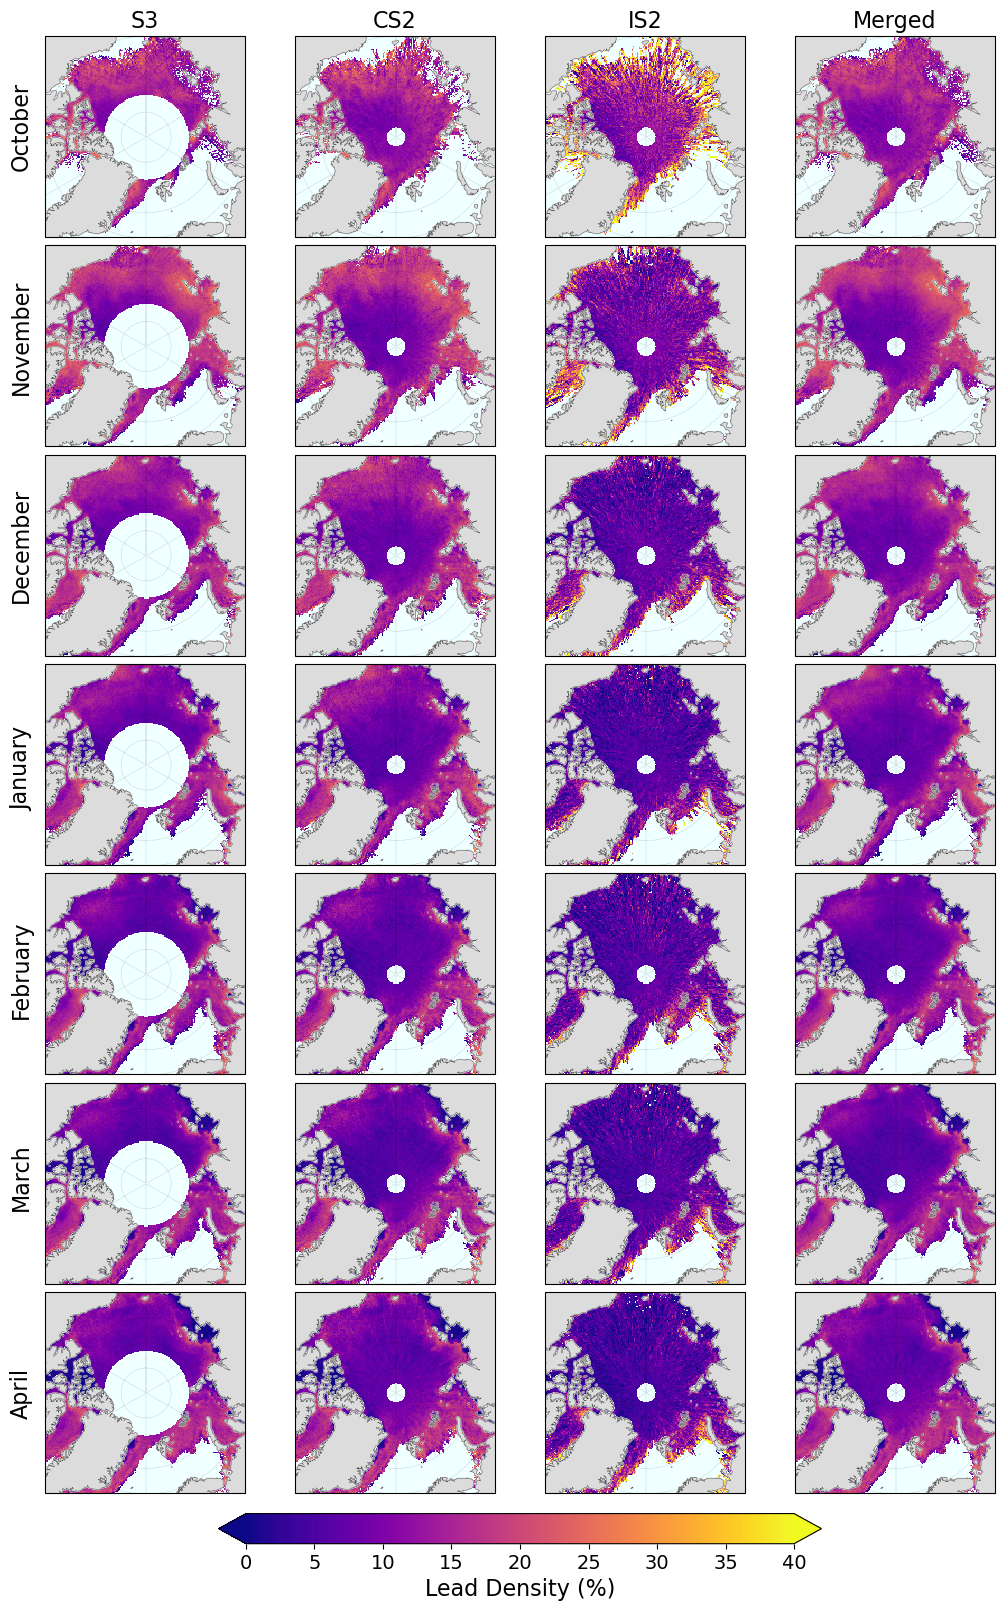

In [16]:
# Only Lead Fraction

lead_datasets = {0: s3_monthly_lead_fractions,1: cs2_monthly_lead_fractions, 
                 2: is2_monthly_lead_fractions,3: merged_monthly_lead_fractions}

months = ['10', '11', '12', '01', '02', '03', '04']

lead_kwargs = dict(cmap='plasma',transform=map_projection,vmin=0,vmax=40,zorder=1)

fig = plt.figure(figsize=(10, 16), layout='constrained')
gs = fig.add_gridspec(7, 4)
ax = np.empty((7, 4), dtype=object)

for row in range(7):
    for col in range(4):
        ax[row, col] = fig.add_subplot(gs[row, col], projection=map_projection)

for col, data in lead_datasets.items(): # Plot lead ma datasets
    for row, month in enumerate(months):
        leads = ax[row, col].pcolormesh(x_grid_centre_25,y_grid_centre_25,
            data[month],**lead_kwargs)

cbar = fig.colorbar(leads,ax=ax[6, 0:4] ,location = 'bottom',shrink=0.8,orientation='horizontal', extend='both', 
                    use_gridspec=True,pad=0.1)
cbar.ax.tick_params(labelsize=14)
cbar.set_label('Lead Density (%)', fontsize=16)


cs2_lead_colour = '#2D74BE'
s3_lead_colour = '#489963'
is2_lead_colour = '#733498'
merged_lead_colour = '#C6482F'


for a in ax[:, :4].flatten():
    a.coastlines(linewidth=0.2,zorder=2.5)
    a.gridlines(linewidth=0.3, color='k', alpha=0.5, linestyle=':')
    a.add_feature(cartopy.feature.LAND, color=('gainsboro'), edgecolor='black',zorder=2)
    a.add_feature(cartopy.feature.OCEAN, color=('azure'),edgecolor='black',zorder=0)
    a.set_extent([-180, 180, 90, 70], ccrs.PlateCarree())


ax[0,0].set_title('S3',fontsize=16)
ax[0,1].set_title('CS2',fontsize=16)
ax[0,2].set_title('IS2',fontsize=16)
ax[0,3].set_title('Merged',fontsize=16)

fig.text(-.01,0.9,'October',fontsize=16,rotation=90)
fig.text(-.01,0.76,'November',fontsize=16,rotation=90)
fig.text(-.01,0.63,'December',fontsize=16,rotation=90)
fig.text(-.01,0.5,'January',fontsize=16,rotation=90)
fig.text(-.01,0.37,'February',fontsize=16,rotation=90)
fig.text(-.01,0.25,'March',fontsize=16,rotation=90)
fig.text(-.01,0.12,'April',fontsize=16,rotation=90)

plt.show()

#fig.savefig('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Arctic_Lead_Density/Figures/Fig2.png',dpi=300,bbox_inches="tight")

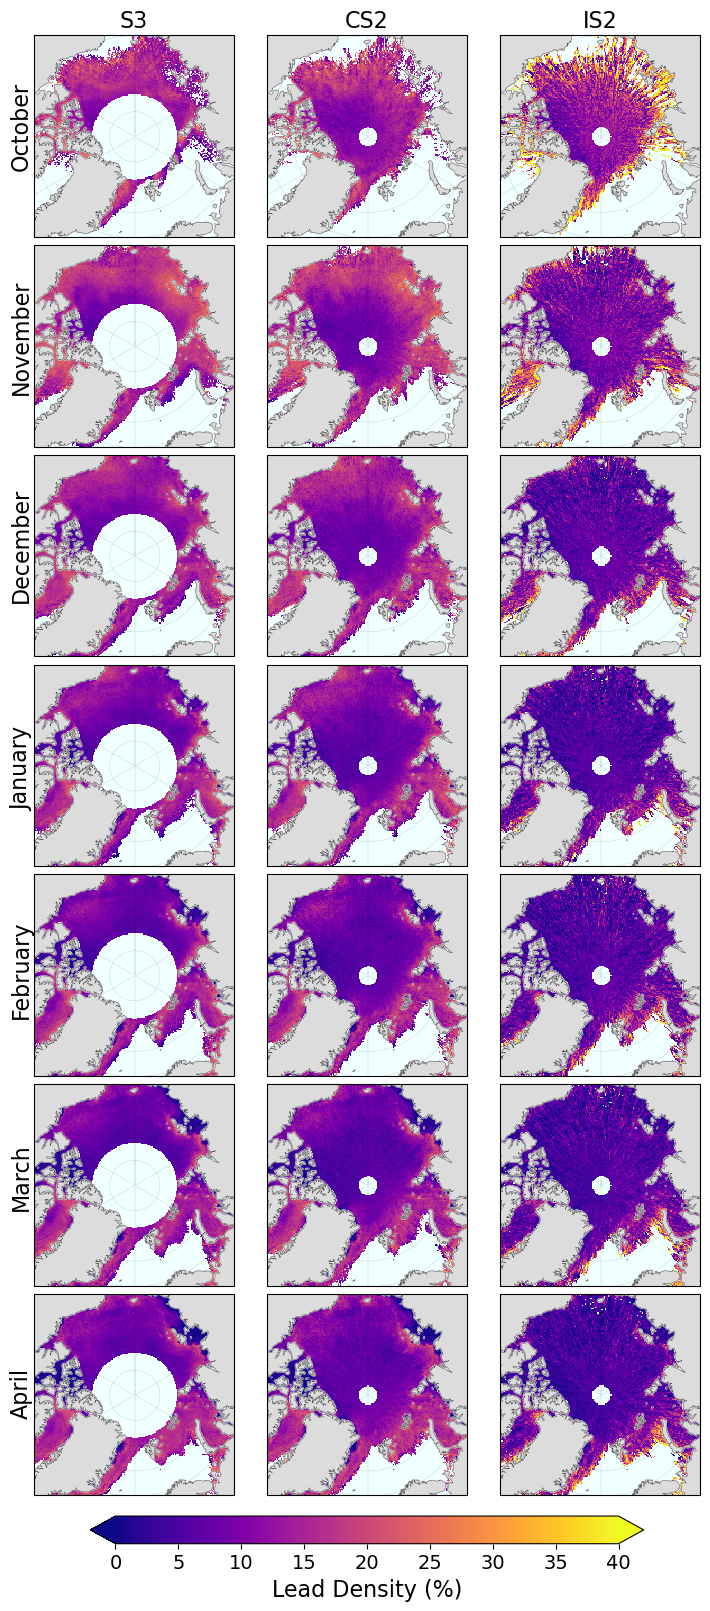

In [27]:
## Only Individual Altimeters

# Only Lead Fraction

lead_datasets = {0: s3_monthly_lead_fractions,1: cs2_monthly_lead_fractions, 
                 2: is2_monthly_lead_fractions}

months = ['10', '11', '12', '01', '02', '03', '04']

lead_kwargs = dict(cmap='plasma',transform=map_projection,vmin=0,vmax=40,zorder=1)

fig = plt.figure(figsize=(7, 16), layout='constrained')
gs = fig.add_gridspec(7, 3)
ax = np.empty((7, 3), dtype=object)

for row in range(7):
    for col in range(3):
        ax[row, col] = fig.add_subplot(gs[row, col], projection=map_projection)

for col, data in lead_datasets.items(): # Plot lead ma datasets
    for row, month in enumerate(months):
        leads = ax[row, col].pcolormesh(x_grid_centre_25,y_grid_centre_25,
            data[month],**lead_kwargs)

cbar = fig.colorbar(leads,ax=ax[6, 0:4] ,location = 'bottom',shrink=0.8,orientation='horizontal', extend='both', 
                    use_gridspec=True,pad=0.1)
cbar.ax.tick_params(labelsize=14)
cbar.set_label('Lead Density (%)', fontsize=16)


cs2_lead_colour = '#2D74BE'
s3_lead_colour = '#489963'
is2_lead_colour = '#733498'


for a in ax[:, :4].flatten():
    a.coastlines(linewidth=0.2,zorder=2.5)
    a.gridlines(linewidth=0.3, color='k', alpha=0.5, linestyle=':')
    a.add_feature(cartopy.feature.LAND, color=('gainsboro'), edgecolor='black',zorder=2)
    a.add_feature(cartopy.feature.OCEAN, color=('azure'),edgecolor='black',zorder=0)
    a.set_extent([-180, 180, 90, 70], ccrs.PlateCarree())


ax[0,0].set_title('S3',fontsize=16)
ax[0,1].set_title('CS2',fontsize=16)
ax[0,2].set_title('IS2',fontsize=16)

fig.text(-.01,0.9,'October',fontsize=16,rotation=90)
fig.text(-.01,0.76,'November',fontsize=16,rotation=90)
fig.text(-.01,0.63,'December',fontsize=16,rotation=90)
fig.text(-.01,0.5,'January',fontsize=16,rotation=90)
fig.text(-.01,0.37,'February',fontsize=16,rotation=90)
fig.text(-.01,0.25,'March',fontsize=16,rotation=90)
fig.text(-.01,0.12,'April',fontsize=16,rotation=90)

plt.show()

#fig.savefig('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Arctic_Lead_Density/Figures/Fig2.png',dpi=300,bbox_inches="tight")

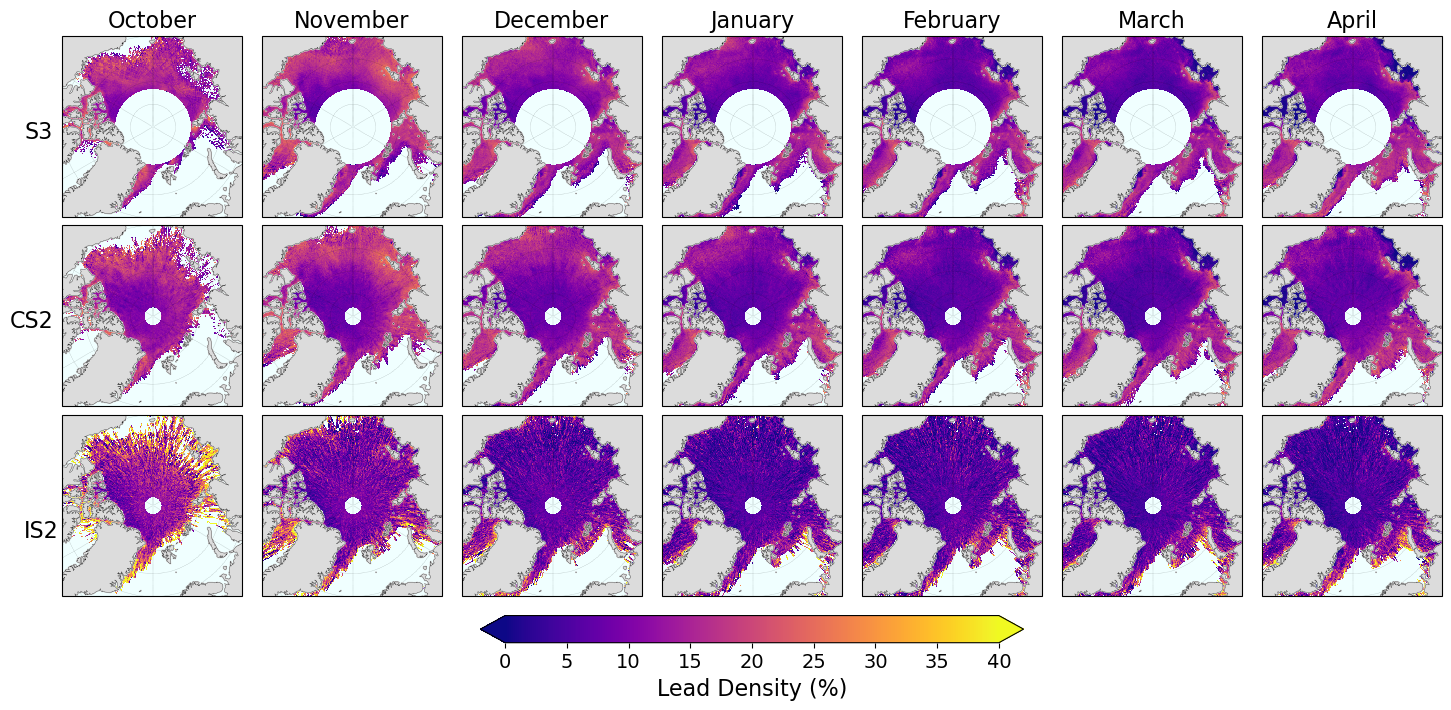

In [38]:
## Only Individual Altimeters

# Only Lead Fraction

lead_datasets = {0: s3_monthly_lead_fractions,1: cs2_monthly_lead_fractions, 
                 2: is2_monthly_lead_fractions}

months = ['10', '11', '12', '01', '02', '03', '04']

lead_kwargs = dict(cmap='plasma',transform=map_projection,vmin=0,vmax=40,zorder=1)

fig = plt.figure(figsize=(14, 7), layout='constrained')
gs = fig.add_gridspec(3, 7)
ax = np.empty((3, 7), dtype=object)

for row in range(3):
    for col in range(7):
        ax[row, col] = fig.add_subplot(gs[row, col], projection=map_projection)

for row, data in lead_datasets.items(): # Plot lead ma datasets
    for col, month in enumerate(months):
        leads = ax[row, col].pcolormesh(x_grid_centre_25,y_grid_centre_25,
            data[month],**lead_kwargs)


cbar = fig.colorbar(leads,ax=ax[2, 0:7] ,location = 'bottom',shrink=0.8,orientation='horizontal', extend='both', 
                    use_gridspec=True,pad=0.1)
cbar.ax.tick_params(labelsize=14)
cbar.set_label('Lead Density (%)', fontsize=16)


cs2_lead_colour = '#2D74BE'
s3_lead_colour = '#489963'
is2_lead_colour = '#733498'


for a in ax.flatten():
    a.coastlines(linewidth=0.2,zorder=2.5)
    a.gridlines(linewidth=0.3, color='k', alpha=0.5, linestyle=':')
    a.add_feature(cartopy.feature.LAND, color=('gainsboro'), edgecolor='black',zorder=2)
    a.add_feature(cartopy.feature.OCEAN, color=('azure'),edgecolor='black',zorder=0)
    a.set_extent([-180, 180, 90, 70], ccrs.PlateCarree())


ax[0,0].set_title('October',fontsize=16)
ax[0,1].set_title('November',fontsize=16)
ax[0,2].set_title('December',fontsize=16)
ax[0,3].set_title('January',fontsize=16)
ax[0,4].set_title('February',fontsize=16)
ax[0,5].set_title('March',fontsize=16)
ax[0,6].set_title('April',fontsize=16)

fig.text(-0.02,0.81,'S3',fontsize=16)
fig.text(-0.03,0.54,'CS2',fontsize=16)
fig.text(-0.02,0.24,'IS2',fontsize=16)

plt.show()

fig.savefig('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Arctic_Lead_Density/Figures/Fig2.png',dpi=300,bbox_inches="tight")